In [107]:
# ── Install any missing packages ─────────────────────────────────────────────
import subprocess, sys

def pip_install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip_install('timm')           # pretrained EfficientNet-B0 / ShuffleNetV2
pip_install('grad-cam')       # pytorch-grad-cam
pip_install('albumentations') # augmentation
pip_install('torchinfo')      # model summary
print('All packages ready.')

All packages ready.


In [108]:
# Kaggle environment -- list all input files
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
# Write up to 20 GB to /kaggle/working/ (preserved as output)
# Temporary files go to /kaggle/temp/ (not saved between sessions)

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/datasets/paultimothymooney

In [109]:
# ── Standard imports ──────────────────────────────────────────────────────────
import os, random, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as tv_models
import timm

# ── Sklearn metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

# ── Grad-CAM ──────────────────────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ── Albumentations ────────────────────────────────────────────────────────────
import albumentations as A
from albumentations.pytorch import ToTensorV2

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


In [110]:
# ── Hyper-parameters & paths ──────────────────────────────────────────────────
class CFG:
    IMG_SIZE     = 224
    IN_CHANS     = 3
    EPOCHS       = 10
    LR           = 3e-4
    WEIGHT_DECAY = 1e-4
    NUM_WORKERS  = 4
    NUM_CLASSES  = 2
    FUSION_DIM   = 256
    LAMR_CHANNELS = 256
    CLASSES      = ['NORMAL', 'PNEUMONIA']
    CKPT_PATH    = '/kaggle/working/best_model.pth'

cfg = CFG()
print('Configuration loaded.')

Configuration loaded.


In [111]:
# =============================================================================
# DATA PREPARATION  --  70 : 15 : 15 split
# =============================================================================
import shutil
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

base_path   = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'
output_path = '/kaggle/working/chest_xray_split'
classes     = ['NORMAL', 'PNEUMONIA']

for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

all_images = {cls: [] for cls in classes}
for split in ['train', 'val', 'test']:
    for cls in classes:
        folder = os.path.join(base_path, split, cls)
        for img in os.listdir(folder):
            img_path = os.path.join(folder, img)
            if os.path.isfile(img_path):
                all_images[cls].append(img_path)

for cls in classes:
    images = all_images[cls]
    random.shuffle(images)
    train_imgs, temp_imgs = train_test_split(images, test_size=0.30, random_state=42)
    val_imgs,  test_imgs  = train_test_split(temp_imgs, test_size=0.50, random_state=42)
    for split_name, split_files in zip(['train', 'val', 'test'],
                                        [train_imgs, val_imgs, test_imgs]):
        for fp in split_files:
            dst = os.path.join(output_path, split_name, cls, os.path.basename(fp))
            shutil.copy(fp, dst)

print('Dataset split complete')

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(os.path.join(output_path, 'train'), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(output_path, 'val'),   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(os.path.join(output_path, 'test'),  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

print(train_dataset.class_to_idx)
print(f'Train: {len(train_dataset)}  Val: {len(val_dataset)}  Test: {len(test_dataset)}')

Dataset split complete
{'NORMAL': 0, 'PNEUMONIA': 1}
Train: 4099  Val: 878  Test: 879


## Attention Modules: ECA & CBAM

In [112]:
# ECA -- Efficient Channel Attention (Wang et al., CVPR 2020)
class ECA(nn.Module):
    """Efficient Channel Attention with adaptive kernel size."""
    def __init__(self, channels: int, gamma: int = 2, b: int = 1):
        super().__init__()
        t  = int(abs(math.log2(channels) / gamma + b / gamma))
        k  = t if t % 2 else t + 1
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        y = self.avg_pool(x)                      # (B, C, 1, 1)
        y = y.squeeze(-1).transpose(-1, -2)        # (B, 1, C)
        y = self.conv(y)                           # (B, 1, C)
        y = y.transpose(-1, -2).unsqueeze(-1)      # (B, C, 1, 1)
        return x * self.sigmoid(y).expand_as(x)


# CBAM -- Convolutional Block Attention Module (Woo et al., ECCV 2018)
class ChannelAttention(nn.Module):
    def __init__(self, channels: int, reduction: int = 16):
        super().__init__()
        reduced = max(channels // reduction, 1)
        self.avg_pool   = nn.AdaptiveAvgPool2d(1)
        self.max_pool   = nn.AdaptiveMaxPool2d(1)
        self.shared_mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels, reduced, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(reduced, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = self.shared_mlp(self.avg_pool(x))
        max_out = self.shared_mlp(self.max_pool(x))
        return x * self.sigmoid(avg_out + max_out).unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size: int = 7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1,  keepdim=True).values
        return x * self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    """Channel then Spatial attention block."""
    def __init__(self, channels: int, reduction: int = 16, spatial_k: int = 7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention(spatial_k)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.sa(self.ca(x))


print('ECA and CBAM modules defined.')

ECA and CBAM modules defined.


## LAMR -- Lesion-Aware Multi-scale Refinement Module

In [113]:
class LAMRBlock(nn.Module):
    """
    Lesion-Aware Multi-scale Refinement block.
    Fuses 1x1, 3x3, 5x5, and global-context branches then applies a
    lesion-sensitive channel gate before adding the residual shortcut.
    """
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        mid = out_channels // 4

        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, 3, padding=1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch5 = nn.Sequential(
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True),
            nn.Conv2d(mid, mid, 5, padding=2, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.branch_global = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, mid, 1, bias=False),
            nn.BatchNorm2d(mid), nn.ReLU(inplace=True)
        )
        self.proj = nn.Sequential(
            nn.Conv2d(mid * 4, out_channels, 1, bias=False),
            nn.BatchNorm2d(out_channels), nn.ReLU(inplace=True)
        )
        gate_mid = max(out_channels // 4, 1)
        self.gate = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(out_channels, gate_mid, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(gate_mid, out_channels, 1),
            nn.Sigmoid()
        )
        self.shortcut = (
            nn.Conv2d(in_channels, out_channels, 1, bias=False)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        b1 = self.branch1(x)
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        bg = self.branch_global(x).expand(B, -1, H, W)
        ms = self.proj(torch.cat([b1, b3, b5, bg], dim=1))
        ms = ms * self.gate(ms)
        return ms + self.shortcut(x)


print('LAMR block defined.')

LAMR block defined.


## Branch Backbones: ShuffleNetV2 + ECA  and  EfficientNet-B0 + CBAM

In [ ]:
# class ShuffleNetV2_ECA(nn.Module):
#     """
#     Branch 1: ShuffleNetV2 (x1.0) + ECA for lightweight local features.
#     Output: (B, proj_dim)
#     """
#     def __init__(self, proj_dim: int = 256, pretrained: bool = True):
#         super().__init__()
#         base     = timm.create_model('shufflenet_v2_x1_0',
#                                      pretrained=pretrained, features_only=False)
#         feat_dim = base.num_features                     # 1024 for x1.0

#         self.backbone = nn.Sequential(*list(base.children())[:-2])  # drop pool+fc
#         self.eca      = ECA(channels=feat_dim)
#         self.gap      = nn.AdaptiveAvgPool2d(1)
#         self.proj     = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(feat_dim, proj_dim),
#             nn.BatchNorm1d(proj_dim),
#             nn.ReLU(inplace=True)
#         )

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         feat = self.backbone(x)
#         feat = self.eca(feat)
#         feat = self.gap(feat)
#         return self.proj(feat)

#     def get_last_conv(self) -> nn.Conv2d:
#         for m in reversed(list(self.backbone.modules())):
#             if isinstance(m, nn.Conv2d):
#                 return m


# class EfficientNetB0_CBAM(nn.Module):
#     """
#     Branch 2: EfficientNet-B0 + CBAM for global semantic + spatial features.
#     Output: (B, proj_dim)
#     """
#     def __init__(self, proj_dim: int = 256, pretrained: bool = True):
#         super().__init__()
#         base     = timm.create_model('efficientnet_b0',
#                                      pretrained=pretrained, features_only=False)
#         feat_dim = base.num_features                     # 1280 for B0

#         self.backbone = base.forward_features
#         self._base    = base
#         self.cbam     = CBAM(channels=feat_dim)
#         self.gap      = nn.AdaptiveAvgPool2d(1)
#         self.proj     = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(feat_dim, proj_dim),
#             nn.BatchNorm1d(proj_dim),
#             nn.ReLU(inplace=True)
#         )

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         feat = self.backbone(x)
#         feat = self.cbam(feat)
#         feat = self.gap(feat)
#         return self.proj(feat)

#     def get_last_conv(self) -> nn.Conv2d:
#         for m in reversed(list(self._base.modules())):
#             if isinstance(m, nn.Conv2d):
#                 return m


# # Quick sanity check
# _dummy = torch.zeros(2, 3, 224, 224)
# _b1 = ShuffleNetV2_ECA(proj_dim=256, pretrained=False)
# _b2 = EfficientNetB0_CBAM(proj_dim=256, pretrained=False)
# print(f'Branch-1 output: {_b1(_dummy).shape}')   # (2, 256)
# print(f'Branch-2 output: {_b2(_dummy).shape}')   # (2, 256)
# del _dummy, _b1, _b2

ShuffleNetV2 + ECA

In [117]:
import torch
import torch.nn as nn
import torchvision.models as models


class ShuffleNetV2_ECA(nn.Module):
    def __init__(self, device, pretrained=True):
        super().__init__()

        # Load ShuffleNetV2 from torchvision
        base = models.shufflenet_v2_x1_0(weights="DEFAULT" if pretrained else None)

        # Feature extractor (remove classifier)
        self.features = base.conv1
        self.maxpool = base.maxpool
        self.stage2 = base.stage2
        self.stage3 = base.stage3
        self.stage4 = base.stage4
        self.conv5 = base.conv5

        # feature dim for x1.0 = 1024
        in_features = 1024

        # Attention
        self.eca = ECA(in_features)

        # pooling
        self.avgpool = nn.AdaptiveAvgPool2d(1)

        # classifier head (same style as EfficientNet)
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

        self.device = device
        self.to(device)

    def forward(self, x):
        x = self.features(x)
        x = self.maxpool(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.conv5(x)

        x = self.eca(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

EfficientNet-B0 + CBAM

In [118]:
import torchvision.models as models
import torch.nn as nn


class EfficientNetB0_CBAM(nn.Module):
    def __init__(self, device, pretrained=True):
        super().__init__()

        base = models.efficientnet_b0(
            weights="DEFAULT" if pretrained else None
        )

        # feature extractor
        self.features = base.features
        self.avgpool = base.avgpool

        # feature dim = 1280
        in_features = base.classifier[1].in_features

        # attention
        self.cbam = CBAM(in_features)

        # classifier head
        self.classifier = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(128, 2)
        )

        self.device = device
        self.to(device)

    def forward(self, x):
        x = self.features(x)
        x = self.cbam(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

b1 = ShuffleNetV2_ECA(device, pretrained=False)
b2 = EfficientNetB0_CBAM(device, pretrained=False)

_dummy = torch.zeros(2, 3, 224, 224).to(device)

print("ShuffleNetV2 output:", b1(_dummy).shape)
print("EfficientNet-B0 output:", b2(_dummy).shape)

ShuffleNetV2 output: torch.Size([2, 2])
EfficientNet-B0 output: torch.Size([2, 2])


## Hybrid Framework -- Dual-Branch + LAMR Refinement

In [121]:
class HybridFramework(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # ❌ WRONG: your class doesn't have proj_dim
        # self.branch1 = ShuffleNetV2_ECA(proj_dim=cfg.FUSION_DIM)

        # ✅ CORRECT: only pass what constructor expects
        self.branch1 = ShuffleNetV2_ECA(
            device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
            pretrained=False
        )

        self.branch2 = EfficientNetB0_CBAM(
            device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
            pretrained=False
        )

        # ⚠️ IMPORTANT: your branches output (B, 2) not feature vectors
        # so FUSION_DIM MUST = 2
        self.fuse_proj = nn.Sequential(
            nn.Linear(4, cfg.LAMR_CHANNELS * 7 * 7),
            nn.ReLU(inplace=True)
        )

        self.lamr = LAMRBlock(cfg.LAMR_CHANNELS, cfg.LAMR_CHANNELS)

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(cfg.LAMR_CHANNELS, cfg.NUM_CLASSES)
        )

    def forward(self, x):
        f1 = self.branch1(x)
        f2 = self.branch2(x)

        fused = torch.cat([f1, f2], dim=1)  # (B, 4)

        B = fused.size(0)
        fused = self.fuse_proj(fused).view(B, -1, 7, 7)

        out = self.gap(self.lamr(fused))
        return self.head(out)

In [ ]:
# import torch
# import torch.nn as nn


# class HybridFramework(nn.Module):
#     """
#     Dual-branch pneumonia detection system:
#       Branch 1: ShuffleNetV2 + ECA
#       Branch 2: EfficientNet-B0 + CBAM
#       Fusion  : concat → FC → reshape → LAMR
#       Head    : classification
#     """

#     def __init__(self, cfg, device=None):
#         super().__init__()

#         self.device = device

#         # --------------------------
#         # Branches
#         # --------------------------
#         self.branch1 = ShuffleNetV2_ECA(
#             proj_dim=cfg.FUSION_DIM,
#             device=device,
#             pretrained=True
#         )

#         self.branch2 = EfficientNetB0_CBAM(
#             proj_dim=cfg.FUSION_DIM,
#             device=device,
#             pretrained=True
#         )

#         # --------------------------
#         # Fusion projection
#         # --------------------------
#         self.fuse_proj = nn.Sequential(
#             nn.Linear(cfg.FUSION_DIM * 2, cfg.LAMR_CHANNELS * 7 * 7),
#             nn.ReLU(inplace=True)
#         )

#         # --------------------------
#         # LAMR refinement block
#         # --------------------------
#         self.lamr = LAMRBlock(cfg.LAMR_CHANNELS, cfg.LAMR_CHANNELS)

#         # --------------------------
#         # Pooling + classifier head
#         # --------------------------
#         self.gap = nn.AdaptiveAvgPool2d(1)

#         self.head = nn.Sequential(
#             nn.Flatten(),
#             nn.Dropout(0.3),
#             nn.Linear(cfg.LAMR_CHANNELS, cfg.NUM_CLASSES)
#         )

#         if device:
#             self.to(device)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:

#         # ensure device consistency
#         if self.device:
#             x = x.to(self.device)

#         # --------------------------
#         # Dual branch feature extraction
#         # --------------------------
#         f1 = self.branch1(x)   # (B, FUSION_DIM)
#         f2 = self.branch2(x)   # (B, FUSION_DIM)

#         # --------------------------
#         # Fusion
#         # --------------------------
#         fused = torch.cat([f1, f2], dim=1)
#         B = fused.size(0)

#         fused = self.fuse_proj(fused)
#         fused = fused.view(B, cfg.LAMR_CHANNELS, 7, 7)

#         # --------------------------
#         # Refinement
#         # --------------------------
#         out = self.lamr(fused)
#         out = self.gap(out)

#         return self.head(out)

In [122]:
# Instantiate model, loss, optimiser, scheduler, and AMP scaler
model = HybridFramework(cfg).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == 'cuda'))

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters : {n_params:,}')
print(f'Optimiser            : AdamW  lr={cfg.LR}  wd={cfg.WEIGHT_DECAY}')
print(f'Scheduler            : CosineAnnealingLR  T_max={cfg.EPOCHS}')

Trainable parameters : 6,129,677
Optimiser            : AdamW  lr=0.0003  wd=0.0001
Scheduler            : CosineAnnealingLR  T_max=10


## Baseline Models -- EfficientNet-B0 & ShuffleNetV2 (standalone comparison)

In [124]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
               epochs, device=DEVICE):
    """Simple training loop for the standalone baseline models."""
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss  += loss.item() * images.size(0)
            _, predicted   = torch.max(outputs.data, 1)
            total_train   += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc  = correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        model.eval()
        val_running_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_running_loss += loss.item() * images.size(0)
                _, predicted      = torch.max(outputs.data, 1)
                total_val        += labels.size(0)
                correct_val      += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / len(val_loader.dataset)
        epoch_val_acc  = correct_val / total_val
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        print(f'Epoch {epoch+1}/{epochs} | '
              f'Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc:.4f} | '
              f'Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc:.4f}')

    print('Finished Training')
    return train_losses, val_losses, train_accs, val_accs

### Baseline 1 -- EfficientNet-B0

In [125]:
# Load pre-trained EfficientNet-B0 using updated weights API
model_efficientnetb0 = tv_models.efficientnet_b0(
    weights=tv_models.EfficientNet_B0_Weights.DEFAULT
)
num_ftrs = model_efficientnetb0.classifier[1].in_features
model_efficientnetb0.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 128),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(128, 2)
)
model_efficientnetb0 = model_efficientnetb0.to(DEVICE)
print('EfficientNet-B0 baseline loaded.')
print(f'Running on: {DEVICE}')

criterion_effb0 = nn.CrossEntropyLoss()
optimizer_effb0 = optim.Adam(model_efficientnetb0.parameters(), lr=0.001)

print('Starting EfficientNet-B0 baseline training...')
train_losses_effb0, val_losses_effb0, train_accs_effb0, val_accs_effb0 = train_model(
    model_efficientnetb0, train_loader, val_loader,
    criterion_effb0, optimizer_effb0, epochs=10
)

EfficientNet-B0 baseline loaded.
Running on: cuda
Starting EfficientNet-B0 baseline training...
Epoch 1/10 | Train Loss: 0.1821  Acc: 0.9297 | Val Loss: 0.0971  Acc: 0.9601
Epoch 2/10 | Train Loss: 0.1376  Acc: 0.9502 | Val Loss: 0.0998  Acc: 0.9601
Epoch 3/10 | Train Loss: 0.1343  Acc: 0.9563 | Val Loss: 0.0883  Acc: 0.9670
Epoch 4/10 | Train Loss: 0.0972  Acc: 0.9680 | Val Loss: 0.1271  Acc: 0.9556
Epoch 5/10 | Train Loss: 0.0921  Acc: 0.9676 | Val Loss: 0.1387  Acc: 0.9624
Epoch 6/10 | Train Loss: 0.0903  Acc: 0.9666 | Val Loss: 0.0729  Acc: 0.9727
Epoch 7/10 | Train Loss: 0.0688  Acc: 0.9756 | Val Loss: 0.2854  Acc: 0.9169
Epoch 8/10 | Train Loss: 0.0760  Acc: 0.9729 | Val Loss: 0.0633  Acc: 0.9727
Epoch 9/10 | Train Loss: 0.0718  Acc: 0.9751 | Val Loss: 0.1376  Acc: 0.9601
Epoch 10/10 | Train Loss: 0.0555  Acc: 0.9807 | Val Loss: 0.0605  Acc: 0.9795
Finished Training


### Baseline 2 -- ShuffleNetV2 (Ultra-light model)

In [ ]:
import torch
import timm
import torchvision.models as models

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# ShuffleNetV2 (torchvision)
# =========================
model_shufflenetv2 = models.shufflenet_v2_x1_0(weights=models.ShuffleNet_V2_X1_0_Weights.DEFAULT)
model_shufflenetv2.fc = nn.Linear(model_shufflenetv2.fc.in_features, 2)
model_shufflenetv2 = model_shufflenetv2.to(DEVICE)


# =========================
# EfficientNet-B0 (timm)
# =========================
model_efficientnetb0 = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=2
)
model_efficientnetb0 = model_efficientnetb0.to(DEVICE)


# =========================
# sanity check
# =========================
_dummy = torch.zeros(2, 3, 224, 224).to(DEVICE)

print("ShuffleNetV2 output:", model_shufflenetv2(_dummy).shape)
print("EfficientNet-B0 output:", model_efficientnetb0(_dummy).shape)

In [129]:
# Build ShuffleNetV2-x1.0 baseline via timm
model_shufflenetv2 = timm.create_model(
    'shufflenet_v2_x1_0', pretrained=True, num_classes=2
)
model_shufflenetv2 = model_shufflenetv2.to(DEVICE)
print('ShuffleNetV2 baseline loaded.')
print(f'Running on: {DEVICE}')

criterion_shufflenetv2 = nn.CrossEntropyLoss()
optimizer_shufflenetv2 = optim.Adam(model_shufflenetv2.parameters(), lr=0.001)

print('Starting ShuffleNetV2 baseline training...')
train_losses_shuff, val_losses_shuff, train_accs_shuff, val_accs_shuff = train_model(
    model_shufflenetv2, train_loader, val_loader,
    criterion_shufflenetv2, optimizer_shufflenetv2, epochs=10
)

RuntimeError: Unknown model (shufflenet_v2_x1_0)

In [132]:
import torch
import timm
import torchvision.models as models
import torch.nn as nn   # ✅ FIX: missing import

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================
# ShuffleNetV2 (torchvision)
# =========================
model_shufflenetv2 = models.shufflenet_v2_x1_0(
    weights=models.ShuffleNet_V2_X1_0_Weights.DEFAULT
)
model_shufflenetv2.fc = nn.Linear(model_shufflenetv2.fc.in_features, 2)
model_shufflenetv2 = model_shufflenetv2.to(DEVICE)

## Hybrid Model Training -- AMP-Accelerated Loops

In [133]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * imgs.size(0)
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []

    for imgs, labels in tqdm(loader, desc='    Val', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        running_loss += loss.item() * imgs.size(0)
        probs         = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds         = logits.argmax(dim=1)
        correct      += (preds == labels).sum().item()
        total        += imgs.size(0)
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / total
    acc      = correct / total
    auc      = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return avg_loss, acc, auc


print('Training functions defined.')

Training functions defined.


In [134]:
# ── Training loop ─────────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [], 'val_auc': []
}
best_val_auc = 0.0

for epoch in range(1, cfg.EPOCHS + 1):
    print(f'\nEpoch [{epoch:02d}/{cfg.EPOCHS}]  lr={scheduler.get_last_lr()[0]:.2e}')

    tr_loss, tr_acc         = train_one_epoch(model, train_loader,
                                              optimizer, criterion, scaler, DEVICE)
    va_loss, va_acc, va_auc = validate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc' ].append(tr_acc)
    history['val_loss'  ].append(va_loss)
    history['val_acc'   ].append(va_acc)
    history['val_auc'   ].append(va_auc)

    print(f'  Train  loss={tr_loss:.4f}  acc={tr_acc:.4f}')
    print(f'  Val    loss={va_loss:.4f}  acc={va_acc:.4f}  AUC={va_auc:.4f}')

    if va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save(model.state_dict(), cfg.CKPT_PATH)
        print(f'  New best model saved  (AUC={best_val_auc:.4f})')

print('\nTraining complete.')


Epoch [01/10]  lr=3.00e-04


  Train:   0%|          | 0/129 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  Train  loss=0.3925  acc=0.8165
  Val    loss=0.3061  acc=0.8554  AUC=0.9476
  New best model saved  (AUC=0.9476)

Epoch [02/10]  lr=2.93e-04


  Train:   0%|          | 0/129 [00:00<?, ?it/s]

...

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  Train  loss=0.1600  acc=0.9454
  Val    loss=0.1342  acc=0.9499  AUC=0.9859
  New best model saved  (AUC=0.9859)

Epoch [10/10]  lr=7.34e-06


  Train:   0%|          | 0/129 [00:00<?, ?it/s]

    Val:   0%|          | 0/28 [00:00<?, ?it/s]

  Train  loss=0.1506  acc=0.9461
  Val    loss=0.1321  acc=0.9499  AUC=0.9869
  New best model saved  (AUC=0.9869)

Training complete.


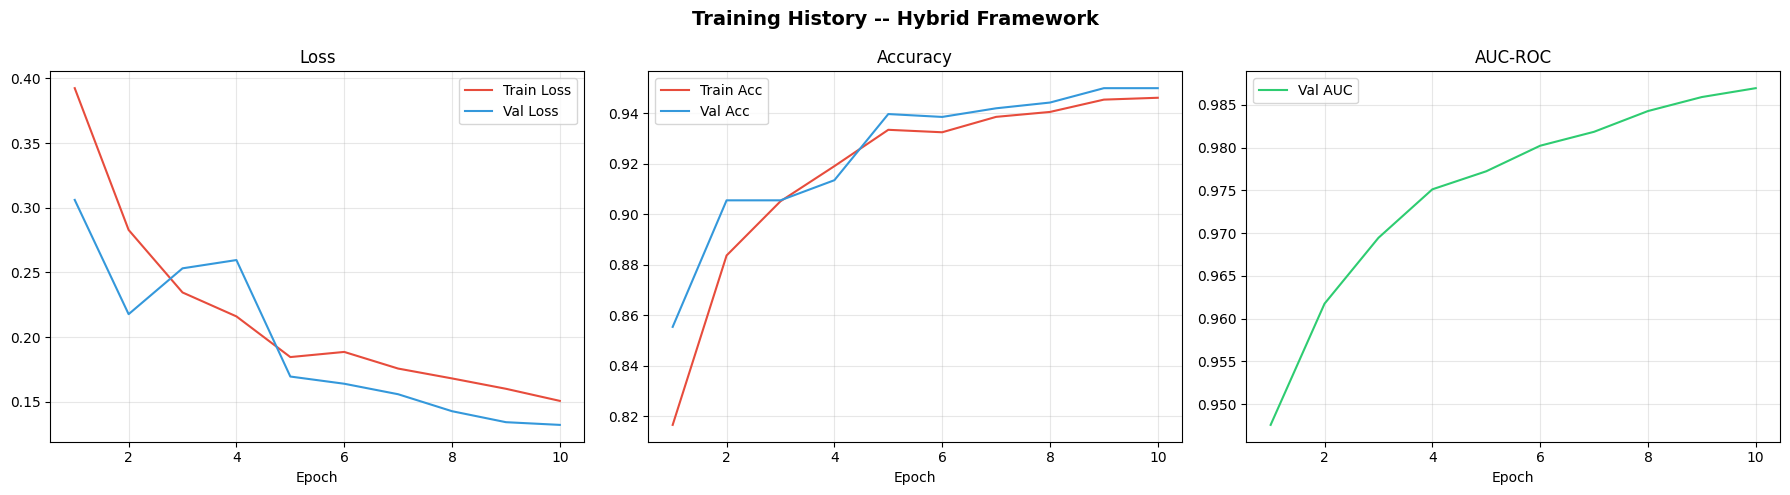

In [135]:
epochs_range = range(1, cfg.EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History -- Hybrid Framework', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   color='#3498db')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', color='#e74c3c')
axes[1].plot(epochs_range, history['val_acc'],   label='Val Acc',   color='#3498db')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(epochs_range, history['val_auc'], label='Val AUC', color='#2ecc71')
axes[2].set_title('AUC-ROC'); axes[2].set_xlabel('Epoch'); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [136]:
# Load best checkpoint
model.load_state_dict(torch.load(cfg.CKPT_PATH, map_location=DEVICE))
model.eval()

@torch.no_grad()
def predict(model, loader, device):
    all_preds, all_probs, all_labels = [], [], []
    for imgs, labels in tqdm(loader, desc='  Test', leave=False):
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_probs), np.array(all_labels)

y_pred, y_prob, y_true = predict(model, test_loader, DEVICE)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
auc  = roc_auc_score(y_true, y_prob)

print('=' * 55)
print('TEST SET PERFORMANCE -- Hybrid Framework')
print('=' * 55)
print(f'  Accuracy  : {acc  * 100:.2f}%')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC-ROC   : {auc:.4f}')
print('=' * 55)
print(classification_report(y_true, y_pred, target_names=cfg.CLASSES))

  Test:   0%|          | 0/28 [00:00<?, ?it/s]

TEST SET PERFORMANCE -- Hybrid Framework
  Accuracy  : 93.97%
  Precision : 0.9594
  Recall    : 0.9579
  F1-Score  : 0.9586
  AUC-ROC   : 0.9815
              precision    recall  f1-score   support

      NORMAL       0.89      0.89      0.89       238
   PNEUMONIA       0.96      0.96      0.96       641

    accuracy                           0.94       879
   macro avg       0.92      0.92      0.92       879
weighted avg       0.94      0.94      0.94       879



## Confusion Matrix

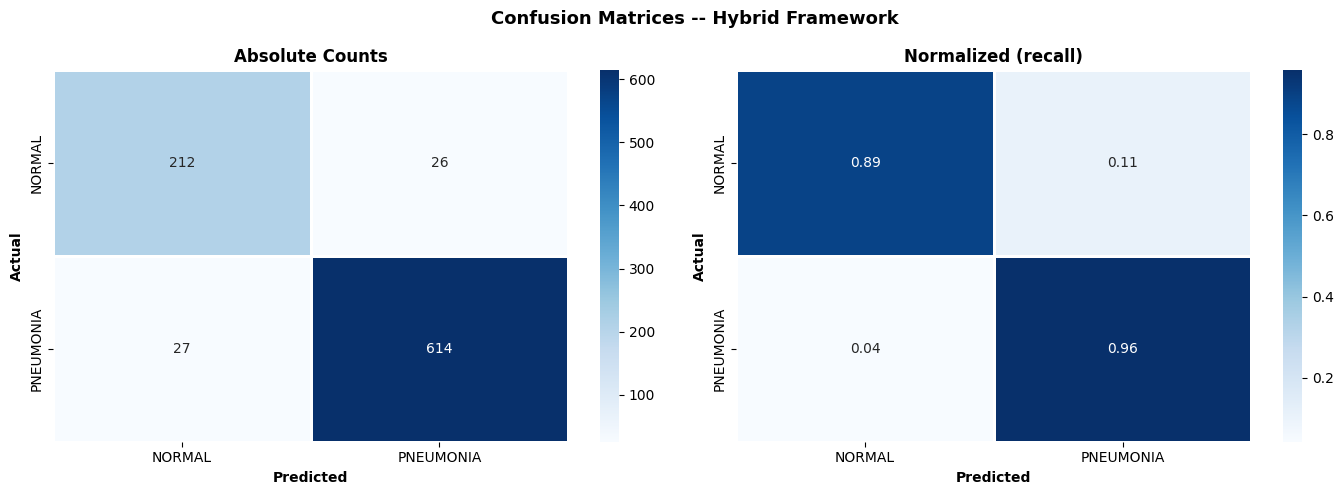

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices -- Hybrid Framework', fontsize=13, fontweight='bold')

for ax, norm, title in zip(axes,
                            [None, 'true'],
                            ['Absolute Counts', 'Normalized (recall)']):
    cm_plot = confusion_matrix(y_true, y_pred, normalize=norm)
    fmt = 'd' if norm is None else '.2f'
    sns.heatmap(cm_plot, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=cfg.CLASSES, yticklabels=cfg.CLASSES,
                linewidths=1, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted', fontweight='bold')
    ax.set_ylabel('Actual',    fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

## ROC Curve

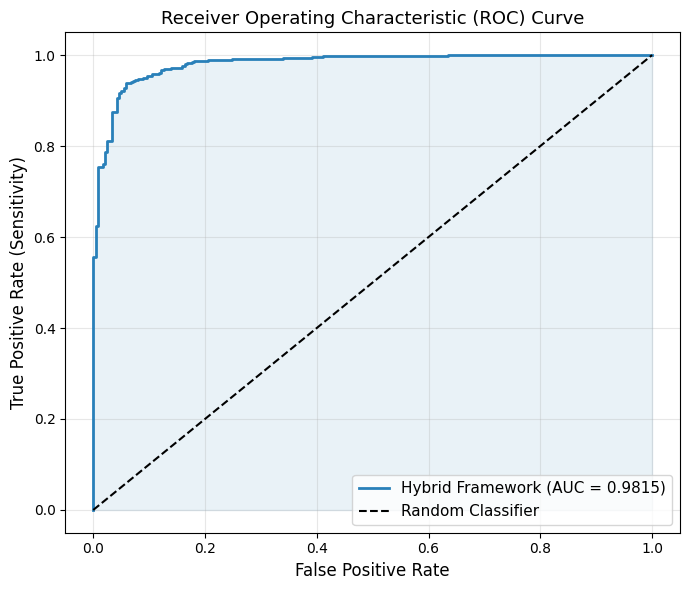

In [138]:
fpr, tpr, _ = roc_curve(y_true, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#2980b9', lw=2,
        label=f'Hybrid Framework (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.1, color='#2980b9')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_curve.png', dpi=150)
plt.show()

## Grad-CAM Visualization

In [139]:
def get_val_transforms():
    """Return the albumentations validation/inference transform pipeline."""
    return A.Compose([
        A.Resize(cfg.IMG_SIZE, cfg.IMG_SIZE),
        A.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
        ToTensorV2()
    ])

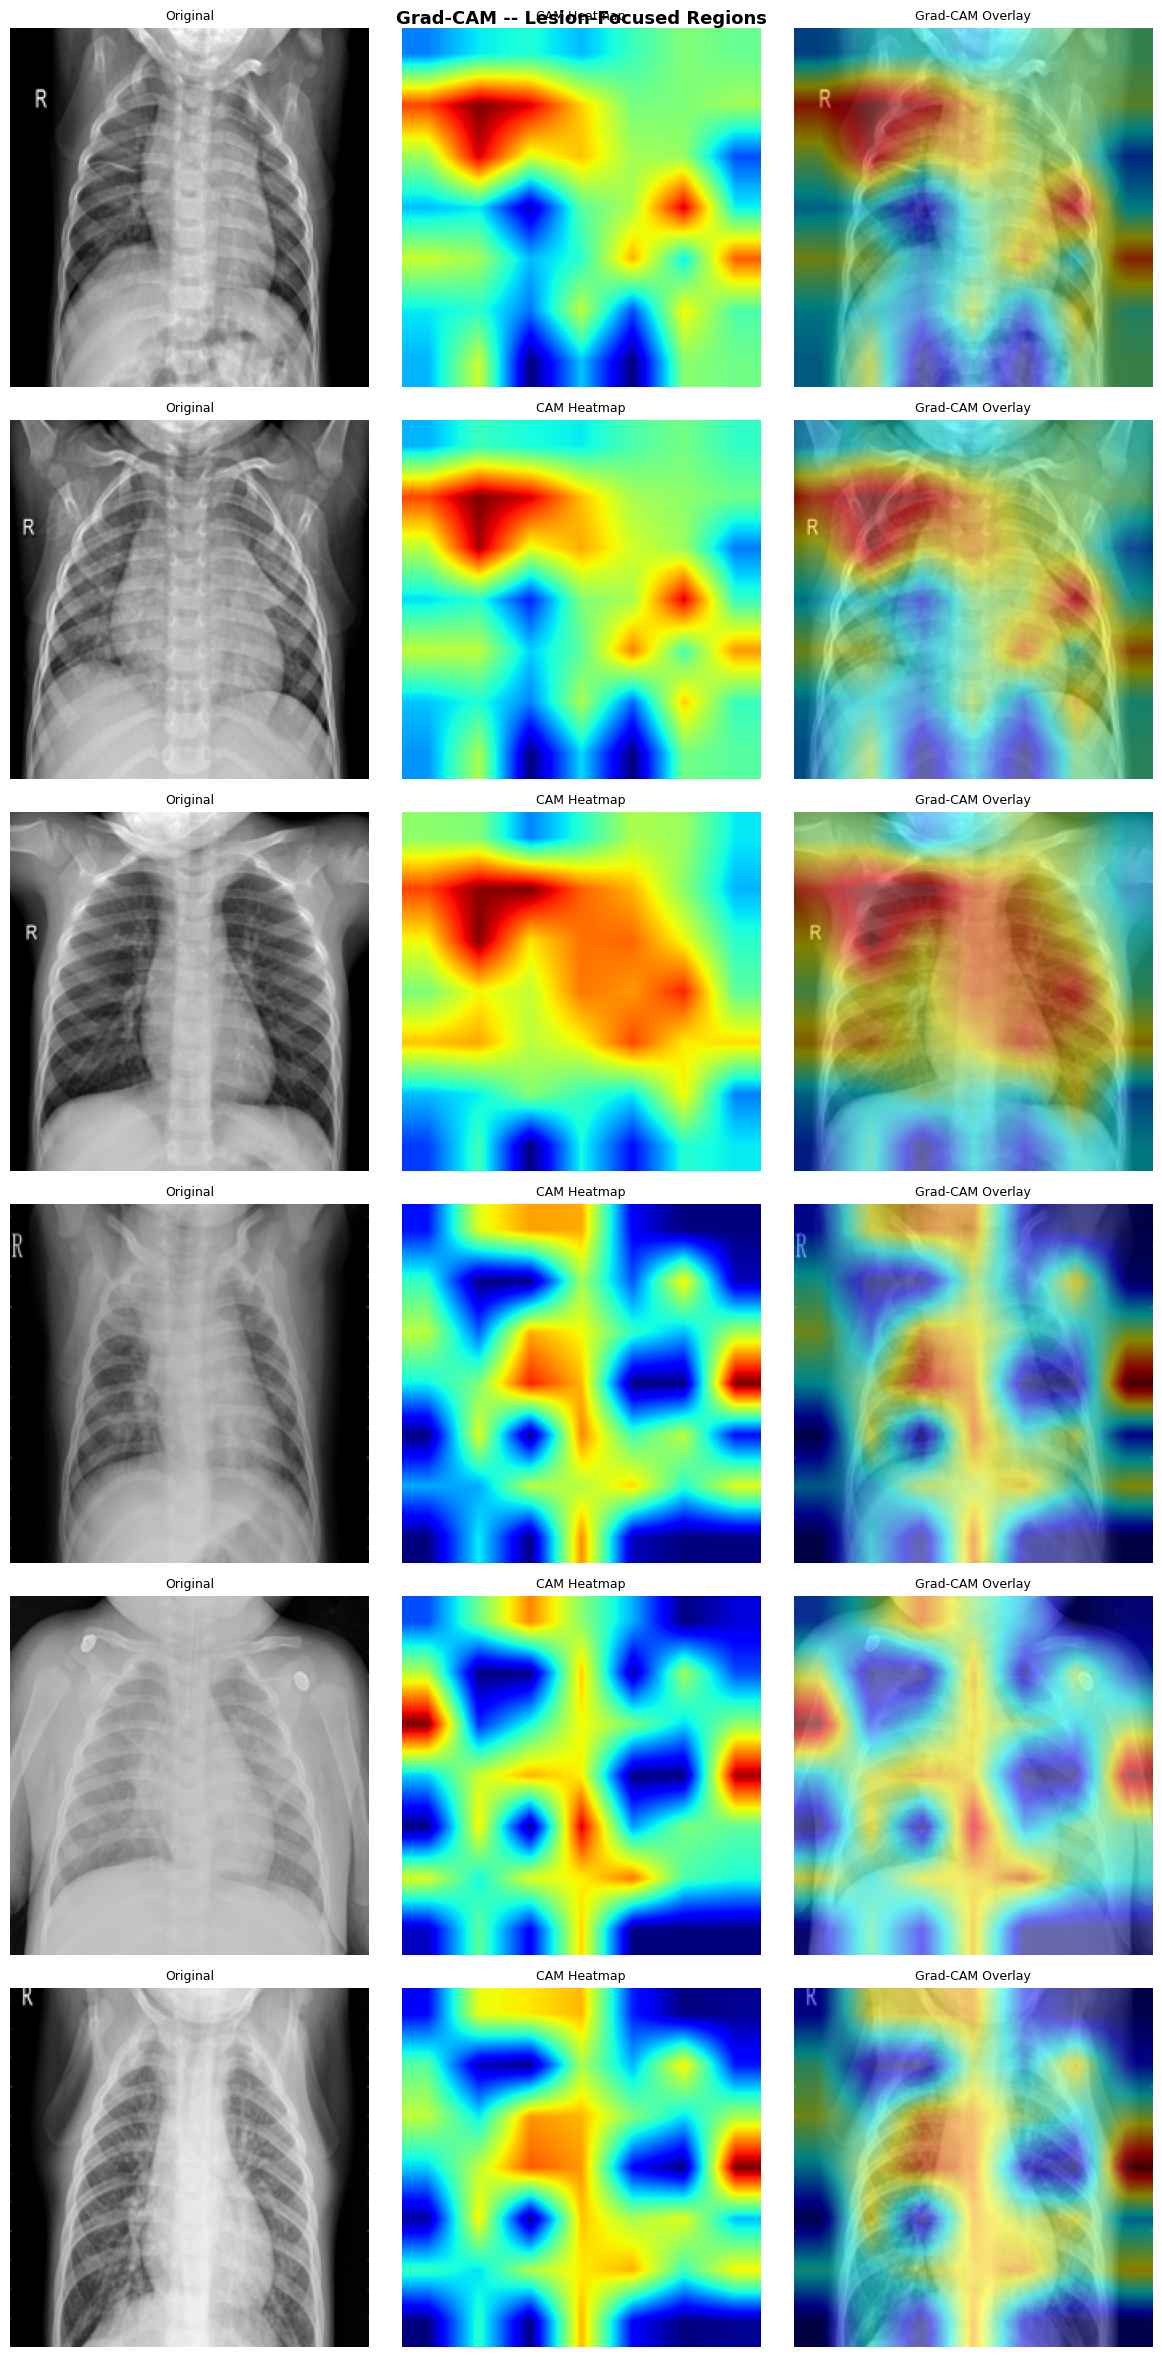

In [144]:
# Grad-CAM target layer -- last BN in LAMR branch5 (5x5 kernel)
target_layer = model.lamr.branch5[-2]

# Fallback to first Conv2d in LAMR proj
try:
    _ = target_layer.weight
except AttributeError:
    target_layer = model.lamr.proj[0]

cam = GradCAM(model=model, target_layers=[target_layer])


def show_gradcam(img_path: Path, label: int, ax_row, transforms_fn):
    """Draw original + Grad-CAM heatmap + overlay for one image."""
    img_np      = np.array(Image.open(img_path).convert('RGB'))
    img_t       = transforms_fn(image=img_np)['image'].unsqueeze(0).to(DEVICE)
    img_resized = np.array(Image.fromarray(img_np).resize((224, 224))) / 255.0

    grayscale_cam = cam(input_tensor=img_t,
                        targets=[ClassifierOutputTarget(label)])[0]
    cam_img = show_cam_on_image(img_resized.astype(np.float32),
                                grayscale_cam, use_rgb=True)

    ax_row[0].imshow(img_resized);               ax_row[0].set_title('Original',         fontsize=9)
    ax_row[1].imshow(grayscale_cam, cmap='jet'); ax_row[1].set_title('CAM Heatmap',      fontsize=9)
    ax_row[2].imshow(cam_img);                   ax_row[2].set_title('Grad-CAM Overlay',  fontsize=9)
    for a in ax_row:
        a.axis('off')


n_samples = 3
val_tf    = get_val_transforms()
fig, axes = plt.subplots(2 * n_samples, 3, figsize=(12, 4 * n_samples * 2))
fig.suptitle('Grad-CAM -- Lesion-Focused Regions', fontsize=13, fontweight='bold')

row = 0
for cls_idx, cls_name in enumerate(cfg.CLASSES):
    cls_samples = [(p, l) for p, l in test_dataset.samples if l == cls_idx]
    chosen      = random.sample(cls_samples, min(n_samples, len(cls_samples)))
    for path, lbl in chosen:
        axes[row, 0].set_ylabel(cls_name, fontsize=10, fontweight='bold',
                                color='green' if cls_idx == 0 else 'red')
        show_gradcam(Path(path), lbl, axes[row], val_tf)
        row += 1

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_visualization.png', dpi=150)
plt.show()

## Architecture Diagram (Text Summary)

In [141]:
try:
    from torchinfo import summary
except ImportError:
    pip_install('torchinfo')
    from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224),
        col_names=['input_size', 'output_size', 'num_params', 'mult_adds'],
        depth=3)

Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #                   Mult-Adds
HybridFramework                                              [1, 3, 224, 224]          [1, 2]                    --                        --
├─ShuffleNetV2_ECA: 1-1                                      [1, 3, 224, 224]          [1, 2]                    --                        --
│    └─Sequential: 2-1                                       [1, 3, 224, 224]          [1, 24, 112, 112]         --                        --
│    │    └─Conv2d: 3-1                                      [1, 3, 224, 224]          [1, 24, 112, 112]         648                       8,128,512
│    │    └─BatchNorm2d: 3-2                                 [1, 24, 112, 112]         [1, 24, 112, 112]         48                        48
│    │    └─ReLU: 3-3                                        [1, 24, 112, 112]         [1, 24, 112, 112]         --                   

## Save Outputs

In [143]:
results_df = pd.DataFrame({
    'true_label'     : y_true,
    'predicted_label': y_pred,
    'prob_pneumonia'  : y_prob,
    'class_true'     : [cfg.CLASSES[l] for l in y_true],
    'class_pred'     : [cfg.CLASSES[l] for l in y_pred],
    'correct'        : y_true == y_pred
})
results_df.to_csv('/kaggle/working/test_predictions.csv', index=False)

metrics_df = pd.DataFrame([{
    'Accuracy' : round(acc,  4),
    'Precision': round(prec, 4),
    'Recall'   : round(rec,  4),
    'F1-Score' : round(f1,   4),
    'AUC-ROC'  : round(auc,  4)
}])
metrics_df.to_csv('/kaggle/working/metrics_summary.csv', index=False)

print('All outputs saved to /kaggle/working/')
print('\nFiles:')
for f in sorted(Path('/kaggle/working/').glob('*')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')

All outputs saved to /kaggle/working/

Files:
  .virtual_documents  (4.0 KB)
  best_model.pth  (24441.4 KB)
  chest_xray_split  (4.0 KB)
  confusion_matrix.png  (62.9 KB)
  gradcam_visualization.png  (3193.3 KB)
  metrics_summary.csv  (0.1 KB)
  roc_curve.png  (70.2 KB)
  test_predictions.csv  (32.9 KB)
  training_curves.png  (131.8 KB)
